# 디지털신호처리 과제 #05
## 201910936 김연수

In [1]:
import thinkdsp
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfft, rfftfreq
from scipy.signal import find_peaks
from IPython.display import display

%matplotlib inline

NOTE_FREQS = {
    'C4': 261.63, 'D4': 293.66, 'E4': 329.63, 'F4': 349.23,
    'G4': 392.00, 'A4': 440.00, 'B4': 493.88,
    'C5': 523.25, 'D5': 587.33, 'E5': 659.25, 'F5': 698.46,
    'G5': 783.99, 'A5': 880.00, 'B5': 987.77,
    'C6': 1046.50
}

def freq_to_note(freq):
    """주파수(Hz)를 가장 가까운 피아노 음계로 변환"""
    best_note, best_diff = None, float('inf')
    for note, nf in NOTE_FREQS.items():
        diff = abs(freq - nf)
        if diff < best_diff:
            best_diff = diff
            best_note = note
    return best_note, best_diff

---
## 문제 1. piano_listen.wav를 read하고 소리를 들어보세요.

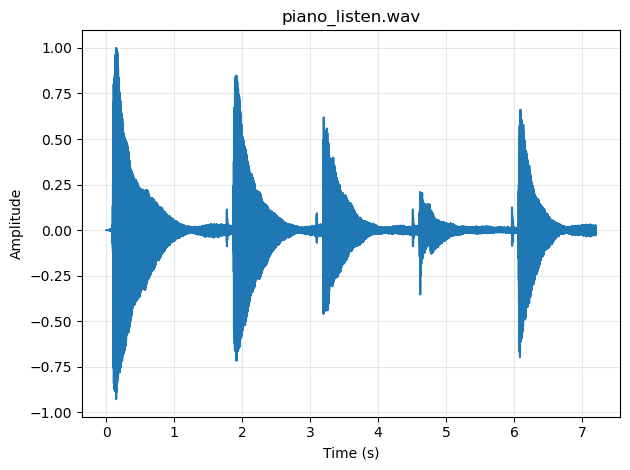

In [14]:
wave = thinkdsp.read_wave('piano_listen.wav')

# plot sound
wave.plot()
plt.title('piano_listen.wav')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

wave.make_audio()

---
## 문제 2. piano_listen.wav의 framerate은?

In [35]:
print(f'{wave.framerate} Hz')


44100 Hz


---
## 문제 3. piano_listen.wav에서는 몇 개의 음계가 포함되어 있는가?

총 길이 : 7.2초
세그먼트: 9개 × 0.8초



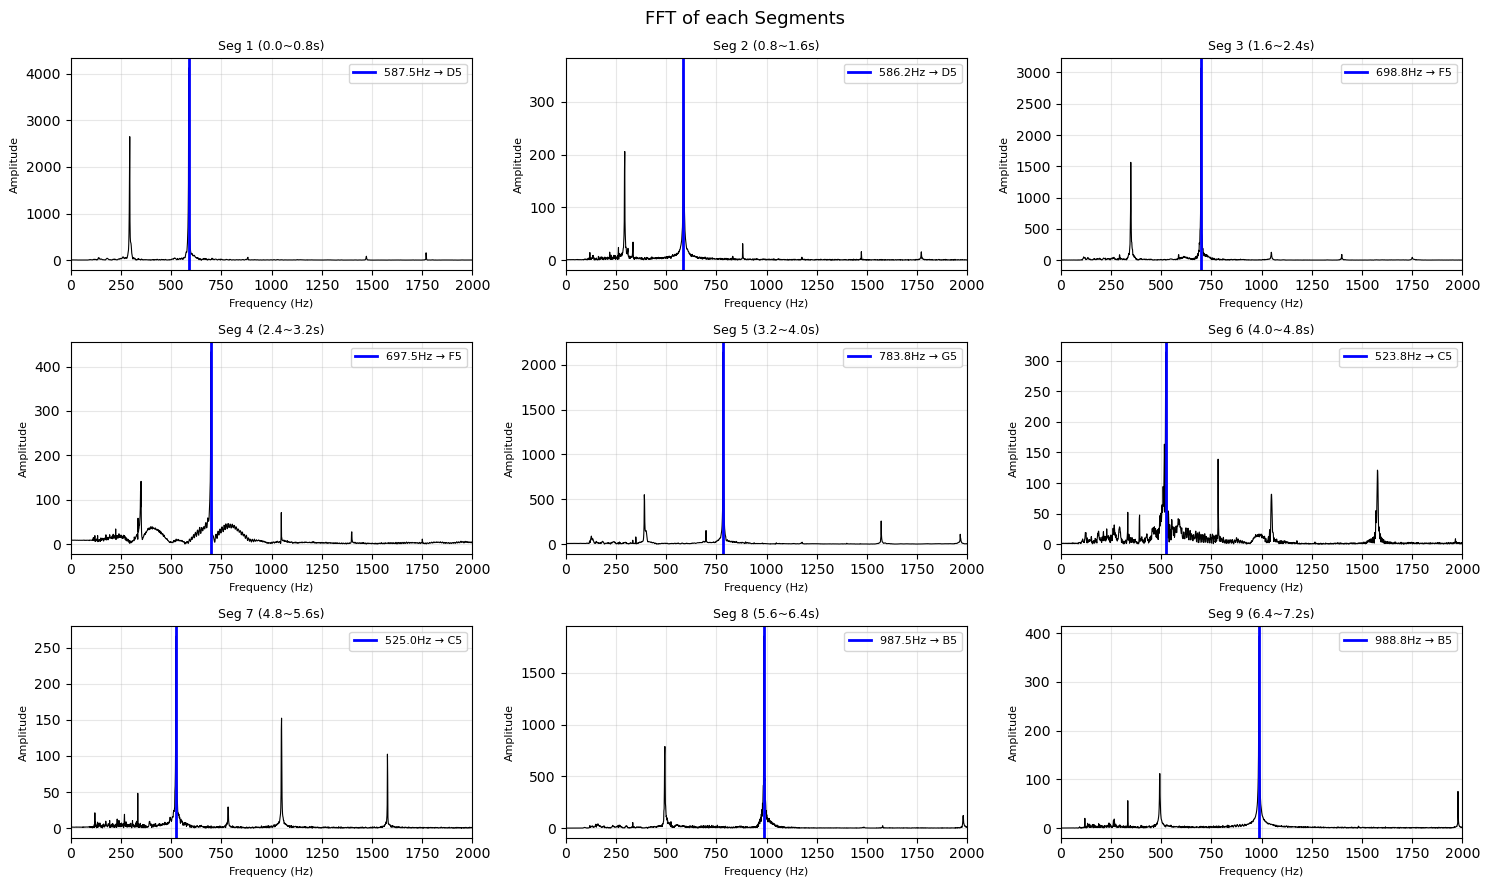

Total Notes : 5


In [18]:
samples   = wave.ys
framerate = wave.framerate

seg_dur = 0.8
seg_len = int(framerate * seg_dur)
n_segs  = len(samples) // seg_len

print(f'총 길이 : {wave.duration:.1f}초')
print(f'세그먼트: {n_segs}개 × {seg_dur}초')
print()

notes_all = []
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
axes = axes.flatten()

for i in range(n_segs):
    seg   = samples[i * seg_len : (i+1) * seg_len]
    fft_v = np.abs(rfft(seg))
    fft_f = rfftfreq(len(seg), 1 / framerate)

    peaks, _ = find_peaks(fft_v, height=np.max(fft_v) * 0.08, distance=20)
    top_idx  = peaks[np.argmax(fft_v[peaks])]
    dom_freq = fft_f[top_idx]
    note, diff = freq_to_note(dom_freq)
    notes_all.append(note)

    ax = axes[i]
    ax.plot(fft_f, fft_v, color='black', linewidth=0.8)
    
    ax.axvline(x=dom_freq,
               color='blue',
               linestyle='-',
               linewidth=2,
               label=f'{dom_freq:.1f}Hz → {note}')
    
    ax.set_xlim(0, 2000)
    ax.set_title(f'Seg {i+1} ({i*seg_dur:.1f}~{(i+1)*seg_dur:.1f}s)', fontsize=9)
    
    ax.set_xlabel('Frequency (Hz)', fontsize=8)
    ax.set_ylabel('Amplitude', fontsize=8)
    
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# hide else
for j in range(n_segs, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('FFT of each Segments', fontsize=13)
plt.tight_layout()
plt.show()

# excluding repeatence
unique_notes = [notes_all[0]]
for n in notes_all[1:]:
    if n != unique_notes[-1]:
        unique_notes.append(n)

print(f'Total Notes : {len(unique_notes)}')

---
## 문제 4. spectrum 분석을 이용하여 piano_listen.wav에 포함되어 있는 음을 모두 순서대로 찾으세요.

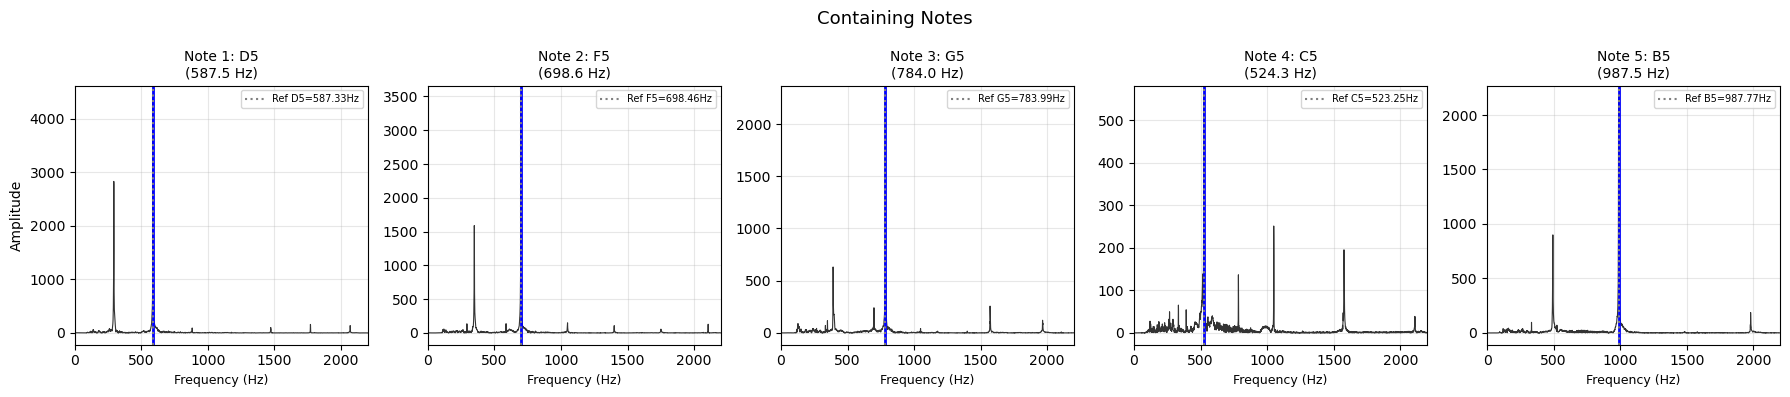

In [28]:
NOTE_DUR  = wave.duration / 5 # each notes are about 1.44 s

spectrum_results = []
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i in range(5):
    t_start = i * NOTE_DUR
    t_end   = (i + 1) * NOTE_DUR
    s_start = int(t_start * framerate)
    s_end   = int(t_end   * framerate)
    seg     = samples[s_start:s_end]

    fft_v = np.abs(rfft(seg))
    fft_f = rfftfreq(len(seg), 1 / framerate)

    peaks, _ = find_peaks(fft_v, height=np.max(fft_v) * 0.08, distance=20)
    top_idx  = peaks[np.argmax(fft_v[peaks])]
    dom_freq = fft_f[top_idx]
    note, diff = freq_to_note(dom_freq)
    spectrum_results.append({'seg': i+1, 'freq': dom_freq, 'note': note, 'diff': diff})

    ax = axes[i]
    ax.plot(fft_f, fft_v, color='black', linewidth=0.8, alpha=0.8)
    ax.axvline(x=dom_freq, color='blue', linestyle='-', linewidth=2)
    
    # note line
    ref_freq = NOTE_FREQS[note]
    ax.axvline(x=ref_freq, 
               color='gray', 
               linestyle=':', 
               linewidth=1.5,
               label=f'Ref {note}={ref_freq}Hz')
    
    ax.set_xlim(0, 2200)
    ax.set_title(f'Note {i+1}: {note}\n({dom_freq:.1f} Hz)', fontsize=10)
    ax.set_xlabel('Frequency (Hz)', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.set_ylabel('Amplitude')

plt.suptitle('Containing Notes', fontsize=13)
plt.tight_layout()
plt.show()

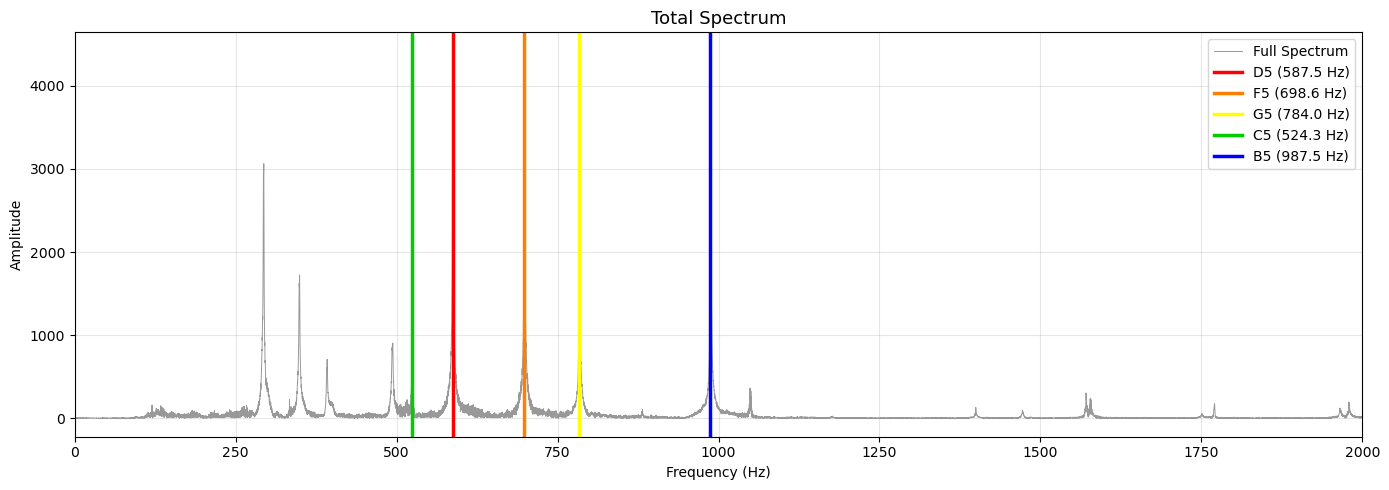

# 1 - D5 [587.50Hz]
# 2 - F5 [698.61Hz]
# 3 - G5 [784.03Hz]
# 4 - C5 [524.31Hz]
# 5 - B5 [987.52Hz]


In [36]:
full_fft_v = np.abs(rfft(samples))
full_fft_f = rfftfreq(len(samples), 1 / framerate)

colors = ['#ff0000', '#ff8000', '#ffff00', '#00cc00', '#0000ff'] # for each color

plt.figure(figsize=(14, 5))
plt.plot(full_fft_f, 
         full_fft_v, 
         color='gray', 
         linewidth=0.7,
         alpha=0.8, label='Full Spectrum')

for idx, r in enumerate(spectrum_results): 
    plt.axvline(x=r['freq'],
                color=colors[idx],
                linestyle='-',
                linewidth=2.5, 
                label=f"{r['note']} ({r['freq']:.1f} Hz)")

plt.xlim(0, 2000)

plt.title('Total Spectrum', fontsize=13)

plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

for r in spectrum_results:
    ref = NOTE_FREQS[r['note']]
    print(f"# {r['seg']} - {r['note']} [{r['freq']:.2f}Hz]")

---
## 문제 5. Autocorrelation으로 음계를 순서대로 찾기

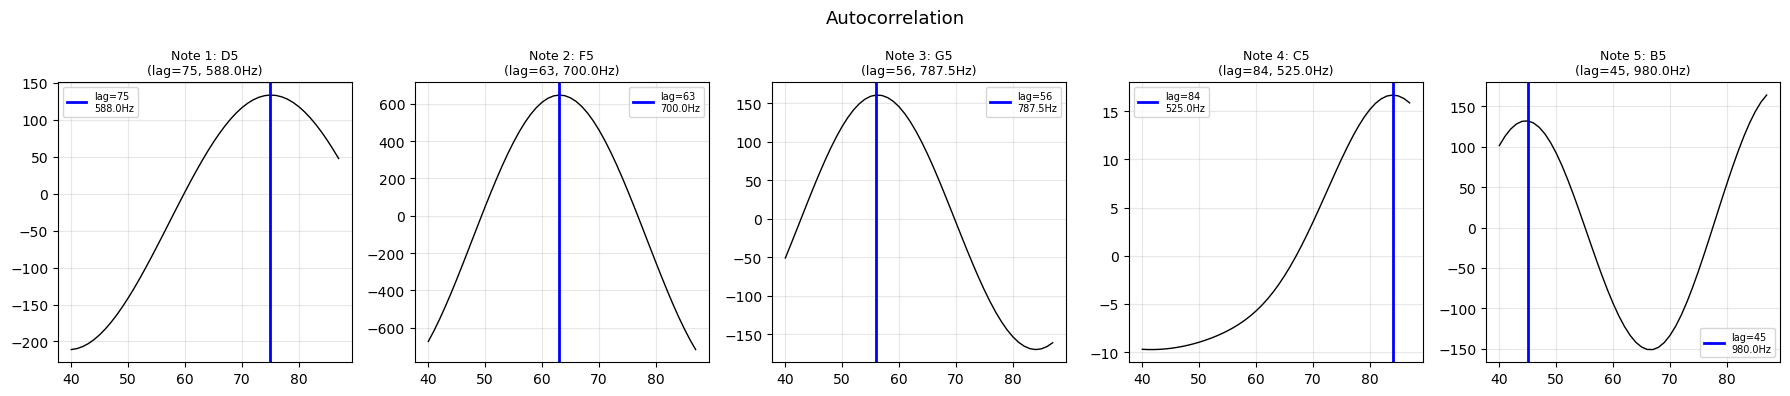

In [39]:
def autocorr_pitch(segment, framerate, fmin=500, fmax=1100):
    seg_norm = segment - np.mean(segment)

    corr = np.correlate(seg_norm, seg_norm, mode='full')
    corr = corr[len(corr) // 2:] 

    lag_min = int(framerate / fmax)
    lag_max = int(framerate / fmin)

    search = corr[lag_min:lag_max]

    peaks, _ = find_peaks(search, height=np.max(search) * 0.25, distance=5)

    if len(peaks) > 0:
        best_lag = peaks[0] + lag_min 
    else:
        best_lag = np.argmax(search) + lag_min  # fallback

    pitch = framerate / best_lag
    return pitch, corr, lag_min, lag_max, best_lag

autocorr_results = []

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i in range(5):
    
    center  = i * NOTE_DUR + NOTE_DUR / 2
    
    # each note +- 0.25
    t_start = center - 0.25
    t_end   = center + 0.25 
    
    s_start = int(t_start * framerate)
    s_end   = int(t_end   * framerate)
    seg     = samples[s_start:s_end]

    pitch, corr, lag_min, lag_max, best_lag = autocorr_pitch(seg, framerate)
    note, diff = freq_to_note(pitch)
    autocorr_results.append({'seg': i+1, 'lag': best_lag, 'freq': pitch,
                              'note': note, 'diff': diff})

    # plot
    lags = np.arange(lag_min, lag_max)
    ax = axes[i]
    
    ax.plot(lags, corr[lag_min:lag_max], color='black', linewidth=1)
    
    ax.axvline(x=best_lag, 
               color='blue', 
               linestyle='-',
               linewidth=2,
               label=f'lag={best_lag}\n{pitch:.1f}Hz')
    
    ax.set_title(f'Note {i+1}: {note}\n(lag={best_lag}, {pitch:.1f}Hz)', fontsize=9)
    
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Autocorrelation', fontsize=13)
plt.tight_layout()
plt.show()

---
## 문제 6. piano_listen.wav를 분석해보고 디지털신호처리 관점에서 느낀점은?

다양한 방법을 통해 소리를 분석하고 분해할 수 있다는 것을 직접 알아볼 수 있었다.

얼핏 무상하게 듣고 넘어갔던 일상 속 소리들에게도 동일한 요소들이 있다는 사실은 새삼 흥미롭게 다가온다.